# Heat pump sizing check
Input: heated area and building type (or a known heat load).
Output: required heat pump capacity and a verdict for each unit in a specific heat pump data sheet table.
Returns verdict as **too small, well sized, or too large** depending on the data sheet values of heat pump.

In [1]:
import pandas as pd

#Data sheet table: Viessmann Vitocal 200-G (brine/water), capacity at B0/W35 in kW
'Source: https://www.viessmann.de/content/dam/public-brands/master/pdf/technology-brochures/de/pr-waermepumpen.pdf/_jcr_content/renditions/original./pr-waermepumpen.pdf'

heatpump_units = pd.DataFrame({"unit": ["201.B06", "201.B08", "201.B10", "201.B13", "201.B17"],
                      "Q_B0W35_kW": [5.8, 7.5, 10.4, 13.2, 17.4]})

#Benchmark values- DIN EN 12831-1
'source: https://www.idm-energie.at/en/heat-pump-installation/heat-loss-calculation/'

specific_load = {"old, uninsulated": 150, 
                 "partly renovated": 100, 
                 "new building standard": 65, 
                 "very efficient": 40}  # W/m2

too_big = 1.3  # above this ratio the unit is considered oversized (30% above the calculated load)

In [15]:
import matplotlib.pyplot as plt
def check(area_m2, building_type, extra_kW=0.0):

    #extra_kW: add e.g. hot water demand,if required.

    load = area_m2 * specific_load[building_type] / 1000 + extra_kW          # kW at design conditions
    t = heatpump_units.copy()
    t["ratio"] = (t.Q_B0W35_kW / load).round(2)
    t["verdict"] = t.ratio.apply(lambda r: "too small" if r < 1 else ("well sized" if r <= too_big else "too large"))

    # chart: data sheet capacity of each unit vs. the heat load
    colors = {"too small": "tab:red", "well sized": "tab:green", "too large": "tab:orange"}
    plt.figure(figsize=(8, 4.5))
    plt.bar(t.unit, t.Q_B0W35_kW, color=t.verdict.map(colors))
    plt.axhline(load, color="k", ls="--", label=f"heat load {load:.1f} kW")
    plt.axhspan(load, load * too_big, color="green", alpha=0.12, label=f"well sized range (1.0 to {too_big} x load)")
    for i, r in enumerate(t.ratio):
        plt.text(i, t.Q_B0W35_kW[i] + 0.3, f"{r:.2f}", ha="center")
    plt.ylabel("heating capacity B0/W35 (kW)"); plt.title(f"{area_m2} m2, {building_type}: unit capacity vs. heat load")
    plt.xlabel("heat pump unit")
    plt.legend(); plt.tight_layout(); plt.show()
    return t


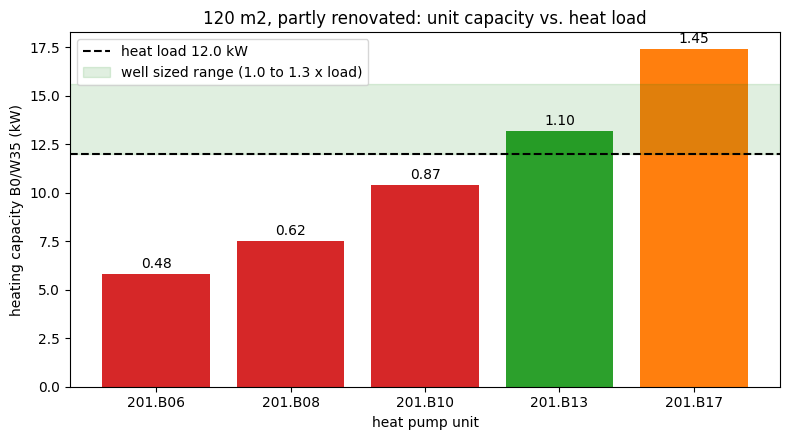

,unit,Q_B0W35_kW,ratio,verdict
0,201.B06,5.8,0.48,too small
1,201.B08,7.5,0.62,too small
2,201.B10,10.4,0.87,too small
3,201.B13,13.2,1.10,well sized
4,201.B17,17.4,1.45,too large


In [16]:
#cheking the sizing for a 120 m2, partly renovated building
check(120, "partly renovated")
